# ReSTIR DI vs Direct (MIS) — Speed & Quality Comparison

Two-pass **ReSTIR Direct Illumination** () vs standard **MIS direct** () in psdr-jit.

| | Direct (MIS) | DirectReSTIR |
|---|---|---|
| Light candidates per pixel | 1 | **M** (WRS selection) |
| Spatial reuse | ✗ | **K** neighbours, radius **r** |
| Shadow rays per pixel/frame | 2 (NEE + BSDF) | M + K |
| Per-frame cost | low | higher |
| Variance per frame | high | much lower |

**Goal**: given an equal wall-clock budget, does ReSTIR's lower per-frame variance outweigh its higher per-frame cost?  
The PSNR-vs-time plot answers that quantitatively.


In [1]:
import time
import numpy as np
import psdr_jit as psdr
import drjit
from drjit.cuda import Float as FloatC, Matrix4f as Matrix4fC
from drjit.cuda.ad import Matrix4f as Matrix4fD

CBOX = '/home/ahc/Documents/psdr-jit/tutorials/data/cbox'
RES  = 256  # resolution — increase for higher quality, decrease for faster runs

# ── Build 256×256 Cornell-box scene (pure psdr_jit, no IRTK) ─────────────────
sc = psdr.Scene()
sc.opts.spp    = 1   # 1 sample per renderC call  →  FPS = 1 / frame_time
sc.opts.sppe   = 0
sc.opts.sppse  = 0
sc.opts.height = RES
sc.opts.width  = RES
sc.opts.log_level = 0

sensor = psdr.PerspectiveCamera(60, 1e-6, 1e7)
sensor.to_world = Matrix4fD([[1.,0.,0.,208.],[0.,1.,0.,273.],[0.,0.,1.,-800.],[0.,0.,0.,1.]])
sc.add_Sensor(sensor)

sc.add_BSDF(psdr.DiffuseBSDF([0.,   0.,   0.  ]), "light")
sc.add_BSDF(psdr.DiffuseBSDF([0.5,  0.5,  0.5 ]), "cat")
sc.add_BSDF(psdr.DiffuseBSDF([0.95, 0.95, 0.95]), "white")
sc.add_BSDF(psdr.DiffuseBSDF([0.20, 0.90, 0.20]), "green")
sc.add_BSDF(psdr.DiffuseBSDF([0.90, 0.20, 0.20]), "red")

I = Matrix4fC([[1.,0.,0.,0.],[0.,1.,0., 0. ],[0.,0.,1.,0.],[0.,0.,0.,1.]])
L = Matrix4fC([[1.,0.,0.,0.],[0.,1.,0.,-0.5],[0.,0.,1.,0.],[0.,0.,0.,1.]])

sc.add_Mesh(f"{CBOX}/cbox_luminaire.obj",  L, "light", psdr.AreaLight([20., 20., 8.]))
sc.add_Mesh(f"{CBOX}/cbox_smallbox.obj",   I, "cat",   None)
sc.add_Mesh(f"{CBOX}/cbox_largebox.obj",   I, "cat",   None)
sc.add_Mesh(f"{CBOX}/cbox_floor.obj",      I, "white", None)
sc.add_Mesh(f"{CBOX}/cbox_ceiling.obj",    I, "white", None)
sc.add_Mesh(f"{CBOX}/cbox_back.obj",       I, "white", None)
sc.add_Mesh(f"{CBOX}/cbox_greenwall.obj",  I, "green", None)
sc.add_Mesh(f"{CBOX}/cbox_redwall.obj",    I, "red",   None)

# Face normals on boxes to avoid shading artefacts at 90° edges
for idx in [1, 2]:
    sc.param_map[f"Mesh[{idx}]"].use_face_normal = True

sc.configure()
print(f"Scene ready: {RES}×{RES}")

Scene ready: 256×256


In [2]:
# ── Integrator configuration ───────────────────────────────────────────────────
N_CANDIDATES   = 8   # M: WRS candidates per pixel
N_NEIGHBORS    = 5   # K: spatial neighbours reused
SPATIAL_RADIUS = 20  # neighbour search radius in pixels

direct_int = psdr.Direct(mis=2)
restir_int = psdr.DirectReSTIR(
    n_candidates   = N_CANDIDATES,
    n_neighbors    = N_NEIGHBORS,
    spatial_radius = SPATIAL_RADIUS,
)

def render_direct(seed: int) -> np.ndarray:
    img = direct_int.renderC(sc, sensor_id=0, seed=seed)
    return img.numpy().reshape(RES, RES, 3)

def render_restir(seed: int) -> np.ndarray:
    img = restir_int.render_restir(sc, sensor_id=0, seed=seed)
    return img.numpy().reshape(RES, RES, 3)

# ── GPU warm-up (first CUDA launch triggers JIT compilation) ──────────────────
print("Warming up GPU kernels…")
for _ in range(3):
    render_direct(0)
    render_restir(0)
print("Done.")

Warming up GPU kernels…
Done.


In [3]:
# ── FPS benchmark (30 frames each, post warm-up) ──────────────────────────────
N_BENCH = 30

t0 = time.perf_counter()
for i in range(N_BENCH):
    render_direct(i)
t_direct = (time.perf_counter() - t0) / N_BENCH

t0 = time.perf_counter()
for i in range(N_BENCH):
    render_restir(i)
t_restir = (time.perf_counter() - t0) / N_BENCH

fps_direct = 1.0 / t_direct
fps_restir = 1.0 / t_restir

print(f"{'Method':<38} {'ms/frame':>10}  {'FPS':>8}")
print("-" * 60)
print(f"{'Direct (MIS, 1 spp)':<38} {t_direct*1e3:>10.1f}  {fps_direct:>8.1f}")
print(f"{'ReSTIR (M=%d K=%d r=%d, 1 spp)' % (N_CANDIDATES, N_NEIGHBORS, SPATIAL_RADIUS):<38} "
      f"{t_restir*1e3:>10.1f}  {fps_restir:>8.1f}")
print(f"\nOverhead: {t_restir/t_direct:.1f}× per frame  "
      f"(~{N_CANDIDATES} cand. + {N_NEIGHBORS} reuse shadow rays vs 2 for Direct)")

Method                                   ms/frame       FPS
------------------------------------------------------------
Direct (MIS, 1 spp)                         224.8       4.4
ReSTIR (M=8 K=5 r=20, 1 spp)               1613.0       0.6

Overhead: 7.2× per frame  (~8 cand. + 5 reuse shadow rays vs 2 for Direct)


In [4]:
# ── High-spp reference for PSNR (300 spp Direct, seeded far from comparison) ──
def psnr(img, ref):
    mse = np.mean((img.astype(np.float64) - ref.astype(np.float64)) ** 2)
    return 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')

print("Building 300-spp reference…")
ref_acc = np.zeros((RES, RES, 3), np.float64)
for i in range(300):
    ref_acc += render_direct(5000 + i)
ref = (ref_acc / 300).clip(0, 1).astype(np.float32)
print("Reference ready.")

Building 300-spp reference…
Reference ready.


In [5]:
# ── Equal wall-clock accumulation ─────────────────────────────────────────────
# Both methods run for TIME_BUDGET seconds.
# A snapshot of the running average is saved every SNAP_INTERVAL seconds.

TIME_BUDGET   = 10.0  # seconds each
SNAP_INTERVAL = 0.5   # seconds between GIF frames


def accumulate(render_fn, budget, snap_interval):
    """Run render_fn until budget is exhausted; snapshot the running mean periodically."""
    frames, timestamps, spps = [], [], []
    acc = np.zeros((RES, RES, 3), np.float64)
    spp = 0
    t_start = t_last = time.perf_counter()
    seed = 0

    while True:
        t_now = time.perf_counter()
        if t_now - t_start >= budget:
            break
        acc += render_fn(seed).astype(np.float64)
        seed += 1
        spp  += 1
        t_now = time.perf_counter()
        if t_now - t_last >= snap_interval:
            frames.append((acc / spp).clip(0, 1).astype(np.float32))
            timestamps.append(t_now - t_start)
            spps.append(spp)
            t_last = t_now

    # Final frame
    frames.append((acc / spp).clip(0, 1).astype(np.float32))
    timestamps.append(time.perf_counter() - t_start)
    spps.append(spp)
    return frames, timestamps, spps


print(f"Accumulating Direct (MIS) for {TIME_BUDGET:.0f}s …")
frames_d, ts_d, spps_d = accumulate(render_direct, TIME_BUDGET, SNAP_INTERVAL)
print(f"  {spps_d[-1]} spp in {ts_d[-1]:.1f}s")

print(f"Accumulating ReSTIR (M={N_CANDIDATES} K={N_NEIGHBORS}) for {TIME_BUDGET:.0f}s …")
frames_r, ts_r, spps_r = accumulate(render_restir, TIME_BUDGET, SNAP_INTERVAL)
print(f"  {spps_r[-1]} spp in {ts_r[-1]:.1f}s")

psnr_d = [psnr(f, ref) for f in frames_d]
psnr_r = [psnr(f, ref) for f in frames_r]
print(f"\nFinal PSNR — Direct: {psnr_d[-1]:.2f} dB  |  ReSTIR: {psnr_r[-1]:.2f} dB")

Accumulating Direct (MIS) for 10s …
  73 spp in 10.1s
Accumulating ReSTIR (M=8 K=5) for 10s …
  36 spp in 10.2s

Final PSNR — Direct: 46.01 dB  |  ReSTIR: 20.71 dB


In [6]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
from IPython.display import HTML

# Align lists to the same number of GIF frames
n_gif   = min(len(frames_d), len(frames_r))
fd, fr  = frames_d[:n_gif], frames_r[:n_gif]
td, tr  = ts_d[:n_gif],     ts_r[:n_gif]
sd, sr  = spps_d[:n_gif],   spps_r[:n_gif]
pd_, pr = psnr_d[:n_gif],   psnr_r[:n_gif]

LBL_D = f"Direct (MIS)  ·  {fps_direct:.0f} FPS"
LBL_R = f"ReSTIR M={N_CANDIDATES} K={N_NEIGHBORS} r={SPATIAL_RADIUS}  ·  {fps_restir:.0f} FPS"

# ── 3-panel animated figure ────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 5.5), facecolor='#111111')
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.06, left=0.02, right=0.98)

ax_d = fig.add_subplot(gs[0]); ax_d.axis('off'); ax_d.set_facecolor('#111111')
ax_r = fig.add_subplot(gs[1]); ax_r.axis('off'); ax_r.set_facecolor('#111111')
ax_p = fig.add_subplot(gs[2]); ax_p.set_facecolor('#1e1e1e')

# Static PSNR curves on the right panel
ax_p.plot(ts_d[:len(psnr_d)], psnr_d, color='#4a9eca', lw=2,   label='Direct (MIS)')
ax_p.plot(ts_r[:len(psnr_r)], psnr_r, color='#e07a3d', lw=2,   label='ReSTIR')
ax_p.set_xlabel('Wall-clock time (s)', color='white', fontsize=10)
ax_p.set_ylabel('PSNR  (dB vs 300-spp ref)', color='white', fontsize=10)
ax_p.set_title('Quality vs. equal time budget', color='white', fontsize=11)
ax_p.tick_params(colors='white')
ax_p.spines[:].set_color('#444444')
ax_p.yaxis.grid(True, color='#333333', zorder=0)
ax_p.legend(loc='lower right', fontsize=9,
            facecolor='#2a2a2a', labelcolor='white', edgecolor='#444444')
cur_d = ax_p.axvline(td[0], color='#4a9eca', lw=1.2, ls='--', alpha=0.7)
cur_r = ax_p.axvline(tr[0], color='#e07a3d', lw=1.2, ls='--', alpha=0.7)

im_d  = ax_d.imshow(fd[0], vmin=0, vmax=1)
im_r  = ax_r.imshow(fr[0], vmin=0, vmax=1)
ttl_d = ax_d.set_title(f'{LBL_D}\nspp={sd[0]}  t={td[0]:.1f}s  {pd_[0]:.1f} dB',
                        color='white', fontsize=9.5, pad=6)
ttl_r = ax_r.set_title(f'{LBL_R}\nspp={sr[0]}  t={tr[0]:.1f}s  {pr[0]:.1f} dB',
                        color='white', fontsize=9.5, pad=6)
fig.suptitle(f'Cornell Box {RES}×{RES} — {TIME_BUDGET:.0f}s equal wall-clock comparison',
             color='white', fontsize=12, y=1.01)


def _update(i):
    im_d.set_data(fd[i])
    im_r.set_data(fr[i])
    ttl_d.set_text(f'{LBL_D}\nspp={sd[i]}  t={td[i]:.1f}s  {pd_[i]:.1f} dB')
    ttl_r.set_text(f'{LBL_R}\nspp={sr[i]}  t={tr[i]:.1f}s  {pr[i]:.1f} dB')
    cur_d.set_xdata([td[i], td[i]])
    cur_r.set_xdata([tr[i], tr[i]])
    return im_d, im_r, ttl_d, ttl_r, cur_d, cur_r


anim = animation.FuncAnimation(fig, _update, frames=n_gif, interval=400, blit=True)
anim.save('restir_comparison.gif', writer='pillow', fps=4, dpi=110)
plt.close()
print("Saved → restir_comparison.gif")

Saved → restir_comparison.gif


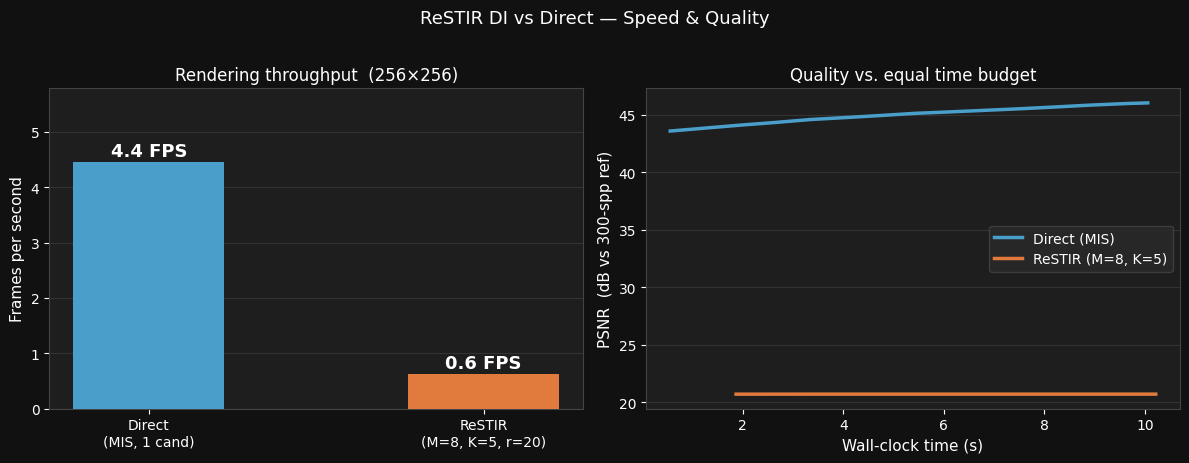

Saved → fps_comparison.png

Summary  (10s wall-clock budget, 256×256)
  Direct :   4.4 FPS  →    73 spp  →  PSNR 46.01 dB
  ReSTIR :   0.6 FPS  →    36 spp  →  PSNR 20.71 dB

  → Direct wins by 25.30 dB at equal time


In [7]:
# ── Static FPS + PSNR summary chart ───────────────────────────────────────────
fig2, (ax_fps, ax_psnr) = plt.subplots(1, 2, figsize=(12, 4.5), facecolor='#111111')

# Left: FPS bars
ax_fps.set_facecolor('#1e1e1e')
labels = [
    f'Direct\n(MIS, 1 cand)',
    f'ReSTIR\n(M={N_CANDIDATES}, K={N_NEIGHBORS}, r={SPATIAL_RADIUS})',
]
vals   = [fps_direct, fps_restir]
colors = ['#4a9eca', '#e07a3d']
bars   = ax_fps.bar(labels, vals, color=colors, width=0.45, zorder=3)
ax_fps.set_ylabel('Frames per second', color='white', fontsize=11)
ax_fps.set_title(f'Rendering throughput  ({RES}×{RES})', color='white', fontsize=12)
ax_fps.tick_params(colors='white')
ax_fps.spines[:].set_color('#444444')
ax_fps.set_ylim(0, max(vals) * 1.3)
ax_fps.yaxis.grid(True, color='#333333', zorder=0)
for bar, v in zip(bars, vals):
    ax_fps.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.025,
                f'{v:.1f} FPS', ha='center', color='white', fontsize=13, fontweight='bold')

# Right: PSNR over time
ax_psnr.set_facecolor('#1e1e1e')
ax_psnr.plot(ts_d[:len(psnr_d)], psnr_d, color='#4a9eca', lw=2.5, label='Direct (MIS)')
ax_psnr.plot(ts_r[:len(psnr_r)], psnr_r, color='#e07a3d', lw=2.5,
             label=f'ReSTIR (M={N_CANDIDATES}, K={N_NEIGHBORS})')
ax_psnr.set_xlabel('Wall-clock time (s)', color='white', fontsize=11)
ax_psnr.set_ylabel('PSNR  (dB vs 300-spp ref)', color='white', fontsize=11)
ax_psnr.set_title('Quality vs. equal time budget', color='white', fontsize=12)
ax_psnr.tick_params(colors='white')
ax_psnr.spines[:].set_color('#444444')
ax_psnr.yaxis.grid(True, color='#333333', zorder=0)
ax_psnr.legend(facecolor='#2a2a2a', labelcolor='white', edgecolor='#444444', fontsize=10)

fig2.suptitle('ReSTIR DI vs Direct — Speed & Quality', color='white', fontsize=13, y=1.02)
plt.tight_layout()
fig2.savefig('fps_comparison.png', dpi=130, bbox_inches='tight', facecolor='#111111')
plt.show()
print("Saved → fps_comparison.png")

print(f"\n{'='*55}")
print(f"Summary  ({TIME_BUDGET:.0f}s wall-clock budget, {RES}×{RES})")
print(f"{'='*55}")
print(f"  Direct : {fps_direct:5.1f} FPS  →  {spps_d[-1]:4d} spp  →  PSNR {psnr_d[-1]:.2f} dB")
print(f"  ReSTIR : {fps_restir:5.1f} FPS  →  {spps_r[-1]:4d} spp  →  PSNR {psnr_r[-1]:.2f} dB")
delta = psnr_r[-1] - psnr_d[-1]
winner = 'ReSTIR' if delta > 0 else 'Direct'
print(f"\n  → {winner} wins by {abs(delta):.2f} dB at equal time")

In [ ]:
# ── Display GIF inline ─────────────────────────────────────────────────────────
HTML(anim.to_jshtml())